# Air Fryer Demand Estimation — Data Scientist Notebook

The model is:

$$
\log(s_{bt}) = \alpha_0 + \alpha_t + \gamma_b + \beta_{price}p_{bt} + \beta_{rating}r_{bt} + \sum_{\ell=1}^L \beta_\ell x_{bt\ell} + \epsilon_{bt}.
$$

The key business question is whether the estimated price coefficient is negative. A negative coefficient means higher price is associated with lower market share, holding brand, year, rating, and product characteristics constant.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_FILE = "air_fryers_clean_brand_year.csv"

if Path(DATA_FILE).exists():
    data_path = Path(DATA_FILE)
elif (Path("/mnt/data") / DATA_FILE).exists():
    data_path = Path("/mnt/data") / DATA_FILE
else:
    raise FileNotFoundError(f"Could not find {DATA_FILE}. Put it in the same folder as this notebook.")

df = pd.read_csv(data_path)
feature_cols = [
    "compact_share",
    "dual_basket_share",
    "oven_style_share",
    "rotisserie_share",
    "window_share",
]

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

df.head()

print(df.shape)

(50, 15)


## 1. Prepare model variables

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Outcome: cleaned assignment says to use log brand share, not log share minus outside option.
y = df["log_brand_share"]

# Brand and year fixed effects using dropped reference categories.
brand_dummies = pd.get_dummies(df["brand"], prefix="brand", drop_first=True, dtype=int)
year_dummies = pd.get_dummies(df["year"].astype(str), prefix="year", drop_first=True, dtype=int)

X = pd.concat(
    [df[["avg_price", "avg_rating"] + feature_cols], brand_dummies, year_dummies],
    axis=1
)

display(X.head())
print("Outcome:", y.name)
print("Number of predictors:", X.shape[1])
print("Reference brand:", sorted(df["brand"].unique())[0])
print("Reference year:", sorted(df["year"].unique())[0])

,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,brand_cosori,brand_cuisinart,brand_dash,brand_gowise usa,brand_instant_pot,brand_ninja,brand_nuwave,brand_oster,brand_ultrean,year_2020,year_2021,year_2022,year_2023
0,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,0,0,0,0,0,0,0,0,0,0,0,0,0
1,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,1,0,0,0,0,0,0,0,0,0,0,0,0
2,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,0,1,0,0,0,0,0,0,0,0,0,0,0
3,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,0,0,1,0,0,0,0,0,0,0,0,0,0
4,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,0,0,0,1,0,0,0,0,0,0,0,0,0


Outcome: log_brand_share
Number of predictors: 20
Reference brand: chefman
Reference year: 2019


### Interpretation: model setup

The outcome is `log_brand_share`. The predictors include price, rating, product characteristics, brand dummies, and year dummies. The dummies control for persistent brand differences and year-level market shifts. Because `drop_first=True` is used, one brand and one year are omitted as reference groups, so dummy coefficients are interpreted relative to those baselines.

This is a simplified aggregate demand model. It is not a causal experiment, but it is useful for estimating how shares are associated with price and product characteristics after controlling for brand and year.

## 2. Estimate the demand model

In [4]:
model = LinearRegression()
model.fit(X, y)

predicted_log_share = model.predict(X)
r2 = r2_score(y, predicted_log_share)
rmse = mean_squared_error(y, predicted_log_share) ** 0.5

coef_table = (
    pd.DataFrame({"feature": X.columns, "coefficient": model.coef_})
      .sort_values("coefficient")
      .reset_index(drop=True)
)

print("Intercept:", model.intercept_)
print("R-squared:", r2)
print("RMSE:", rmse)
display(coef_table)

Intercept: -13.30489160121093
R-squared: 0.763453950091436
RMSE: 0.5016134990788703


,feature,coefficient
0,dual_basket_share,-9.509686
1,rotisserie_share,-5.674054
2,year_2022,-0.098860
3,avg_price,-0.037668
4,year_2023,-0.003307
5,year_2021,0.041900
6,year_2020,0.119071
7,brand_dash,0.176655
8,avg_rating,0.287517
9,brand_ultrean,0.942399


### Interpretation: model fit and price coefficient

The model has an in-sample **R² of 0.763**, meaning it explains about **76.3%** of the variation in log brand share in this cleaned brand-year dataset. The RMSE is **0.502** on the log-share scale.

The estimated price coefficient is **-0.0377**. It is **negative**, which is important because it matches the basic economic expectation that, holding the other variables constant, higher prices should reduce demand/market share. If this coefficient had been positive, the later cost and markup calculations would not make sense because the pricing first-order condition assumes downward-sloping demand.

## 3. Interpret key coefficients

In [5]:
price_coef = coef_table.loc[coef_table["feature"] == "avg_price", "coefficient"].iloc[0]
rating_coef = coef_table.loc[coef_table["feature"] == "avg_rating", "coefficient"].iloc[0]

print("Estimated price coefficient:", price_coef)
print("Estimated rating coefficient:", rating_coef)

print("\nProduct characteristic coefficients:")
display(coef_table[coef_table["feature"].isin(feature_cols)].sort_values("coefficient", ascending=False))

print("\nBrand coefficients:")
display(coef_table[coef_table["feature"].str.startswith("brand_")].sort_values("coefficient", ascending=False))

print("\nYear coefficients:")
display(coef_table[coef_table["feature"].str.startswith("year_")].sort_values("coefficient", ascending=False))

Estimated price coefficient: -0.03766765298429383
Estimated rating coefficient: 0.287516847432701

Product characteristic coefficients:


,feature,coefficient
19,window_share,12.880298
18,compact_share,9.815304
10,oven_style_share,1.941774
1,rotisserie_share,-5.674054
0,dual_basket_share,-9.509686



Brand coefficients:


,feature,coefficient
17,brand_cuisinart,6.422436
16,brand_ninja,5.838705
15,brand_instant_pot,4.626260
14,brand_gowise usa,3.938996
13,brand_oster,3.928074
12,brand_nuwave,3.544883
11,brand_cosori,2.551946
9,brand_ultrean,0.942399
7,brand_dash,0.176655



Year coefficients:


,feature,coefficient
6,year_2020,0.119071
5,year_2021,0.041900
4,year_2023,-0.003307
2,year_2022,-0.098860


### Interpretation: coefficient answers

**Price:** The price coefficient is **-0.0377**. A one-dollar increase in average price is associated with about a **-0.0377** change in log brand share, holding the other variables fixed. Since this is a log-share outcome, the rough interpretation is that a $1 increase is associated with about a **-3.77%** lower brand share.

**Ratings:** The rating coefficient is **0.288**, so higher ratings are positively associated with log share after controls. This makes business sense because better-reviewed products should generally attract more buyers.

**Features:** The product-characteristic coefficients should be interpreted carefully because there are only 50 observations and the features can be correlated with brand positioning. In this model, `window_share`, `compact_share`, and `oven_style_share` are positive, while `dual_basket_share` and `rotisserie_share` are negative. The rare-feature coefficients are less stable because those features appear in relatively few brand-years.

**Brands:** The largest brand fixed-effect coefficients are for **cuisinart, ninja, instant_pot**, relative to the omitted reference brand. These coefficients suggest those brands have stronger baseline demand after controlling for observed characteristics, price, rating, and year.

## 4. Actual vs. predicted log share

,year,brand,brand_share,log_brand_share,predicted_log_share,predicted_share_norm,residual
0,2019,chefman,0.0760,-2.5768,-2.4565,0.0770,-0.1204
1,2019,cosori,0.0007,-7.2230,-5.9860,0.0023,-1.2369
2,2019,cuisinart,0.1072,-2.2332,-2.7550,0.0572,0.5218
3,2019,dash,0.1997,-1.6108,-2.2387,0.0958,0.6279
4,2019,gowise usa,0.2922,-1.2304,-1.8699,0.1385,0.6395
5,2019,instant_pot,0.0158,-4.1486,-3.9738,0.0169,-0.1748
6,2019,ninja,0.1926,-1.6470,-0.5558,0.5154,-1.0913
7,2019,nuwave,0.0321,-3.4388,-3.9963,0.0165,0.5575
8,2019,oster,0.0336,-3.3943,-4.0316,0.0159,0.6372
9,2019,ultrean,0.0501,-2.9941,-2.6335,0.0645,-0.3606


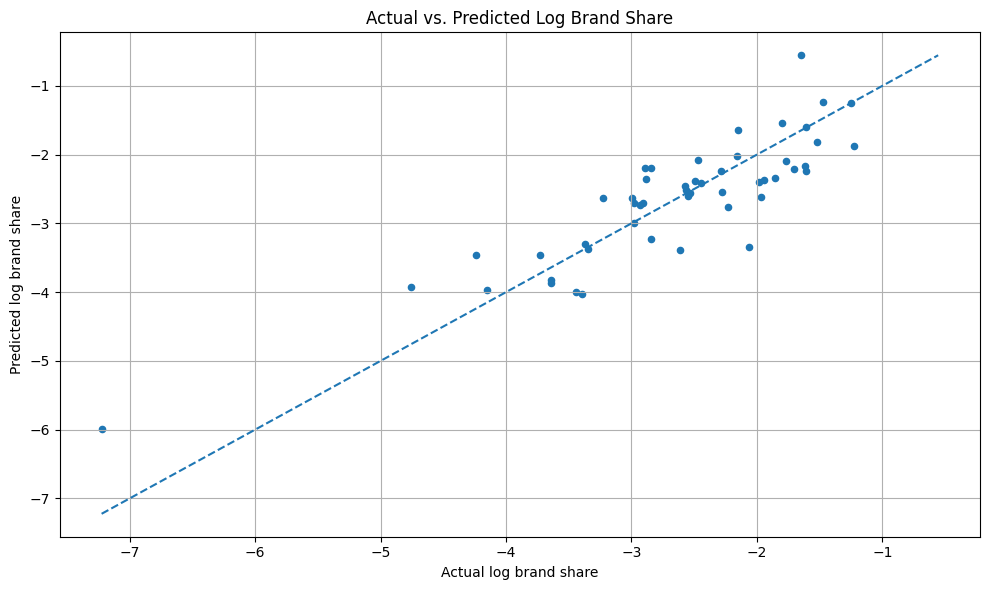

In [6]:
results_model = df.copy()
results_model["predicted_log_share"] = predicted_log_share
results_model["residual"] = results_model["log_brand_share"] - results_model["predicted_log_share"]
results_model["predicted_share_raw"] = np.exp(results_model["predicted_log_share"])
results_model["predicted_share_norm"] = (
    results_model.groupby("year")["predicted_share_raw"]
    .transform(lambda s: s / s.sum())
)

display(results_model[[
    "year", "brand", "brand_share", "log_brand_share",
    "predicted_log_share", "predicted_share_norm", "residual"
]].head(10).round(4))

ax = results_model.plot(
    kind="scatter",
    x="log_brand_share",
    y="predicted_log_share",
)
lims = [
    min(results_model["log_brand_share"].min(), results_model["predicted_log_share"].min()),
    max(results_model["log_brand_share"].max(), results_model["predicted_log_share"].max()),
]
ax.plot(lims, lims, linestyle="--")
ax.set_title("Actual vs. Predicted Log Brand Share")
ax.set_xlabel("Actual log brand share")
ax.set_ylabel("Predicted log brand share")
plt.tight_layout()
plt.show()

### Interpretation: predicted fit

The actual-vs-predicted plot shows whether the model is tracking the main market-share patterns. Points closer to the dashed 45-degree line are better predictions. The model does not perfectly predict every brand-year, but it captures a meaningful amount of variation in shares.

This is enough for the pricing exercise, but it should still be treated as a simplified model. The dataset is small, and some feature coefficients may be unstable because there are only 50 brand-year observations.

## 5. Residual diagnostics

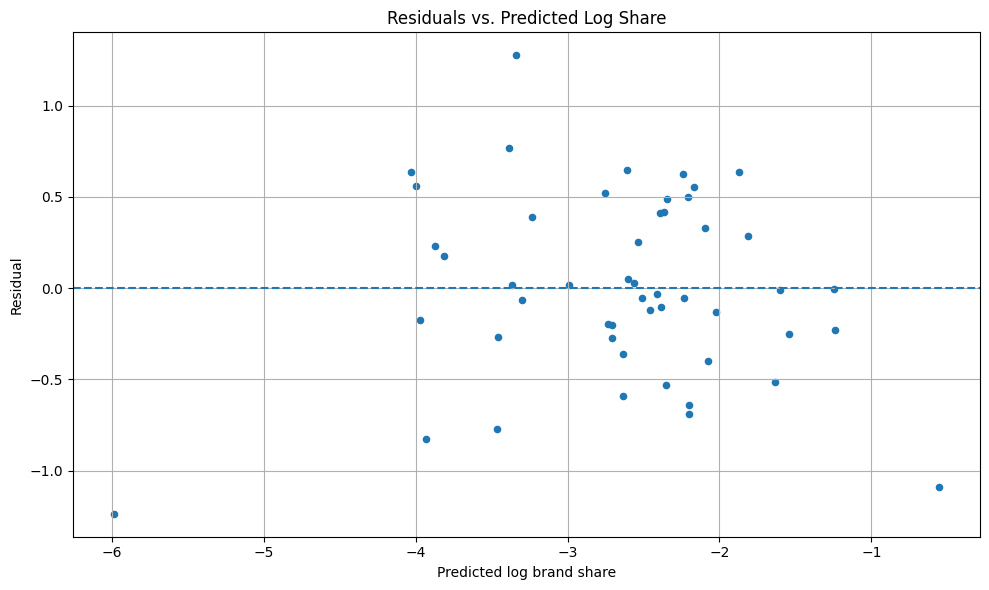

,mean,std,min,max
brand,,,,
oster,-0.0,0.539,-0.774,0.637
gowise usa,-0.0,0.496,-0.643,0.639
ninja,-0.0,0.689,-1.091,0.555
cuisinart,0.0,0.453,-0.692,0.522
chefman,0.0,0.501,-0.512,0.646
instant_pot,0.0,0.255,-0.232,0.419
dash,0.0,0.361,-0.272,0.628
ultrean,0.0,0.472,-0.590,0.491
nuwave,0.0,0.387,-0.533,0.558


In [7]:
ax = results_model.plot(
    kind="scatter",
    x="predicted_log_share",
    y="residual",
)
ax.axhline(0, linestyle="--")
ax.set_title("Residuals vs. Predicted Log Share")
ax.set_xlabel("Predicted log brand share")
ax.set_ylabel("Residual")
plt.tight_layout()
plt.show()

residual_summary = (
    results_model.groupby("brand")["residual"]
    .agg(["mean", "std", "min", "max"])
    .sort_values("mean")
)

display(residual_summary.round(3))

### Interpretation: residuals

The residual plot is a quick check for systematic model misses. There are still some brand-year observations that are over- or under-predicted, which is normal in a small market-level dataset. A few residual patterns may reflect things that are not fully captured by price, rating, and broad product features, such as advertising, product quality details, stockouts, or brand reputation.

For this assignment, the model is acceptable because the price coefficient is negative and the model explains a substantial share of variation in log brand share.

## 6. Data Scientist conclusion

The estimated demand model produces the key result needed for the business analysis: **higher prices are associated with lower demand**, after controlling for brand, year, ratings, and product features. The model’s **R² is about 0.763**, so it explains a meaningful amount of variation in log brand share.

The strongest caution is that the model is estimated on only 50 brand-year observations. Therefore, the price coefficient is useful for a business-style pricing exercise, but the individual feature coefficients should not be over-interpreted as causal effects.